In [1]:
# Goal: The script will run a one-sample t-test testing whether the mean of Age equals 50.


# Cell 1 — Imports
# - pandas for reading Excel
# - scipy.stats for the one-sample t-test
# - google.colab.files for upload/download

import pandas as pd
from scipy import stats
from google.colab import files


In [2]:
# Cell 2 — Upload the Excel input file
# Choose: one_sample_ttest_data.xlsx

uploaded = files.upload()
input_filename = list(uploaded.keys())[0]
print("Uploaded file:", input_filename)



Saving one_sample_ttest_data.xlsx to one_sample_ttest_data.xlsx
Uploaded file: one_sample_ttest_data.xlsx


In [3]:
# Cell 3 — Read Excel
data = pd.read_excel(input_filename, sheet_name=0)

print("Data shape (rows, columns):", data.shape)
print("Column names:", list(data.columns))
data


Data shape (rows, columns): (8, 1)
Column names: ['Age']


,Age
0,45
1,54
2,36
3,15
4,18
5,36
6,19
7,21


In [5]:
# Cell 4 — Extract the sample data

sample_data = pd.to_numeric(data["Age"], errors="coerce").dropna()

print("Number of observations used:", len(sample_data))
print("Sample mean:", float(sample_data.mean()))
print("Sample std (sample SD):", float(sample_data.std(ddof=1)))

# If a value cannot be converted to a number, errors="coerce" replaces it with NaN. We then drop NaN by using dropna()”
# ddof=1 tells Python we are working with a sample, not the full population. ddof=0 is for population std


Number of observations used: 8
Sample mean: 30.5
Sample std (sample SD): 14.352700094407323


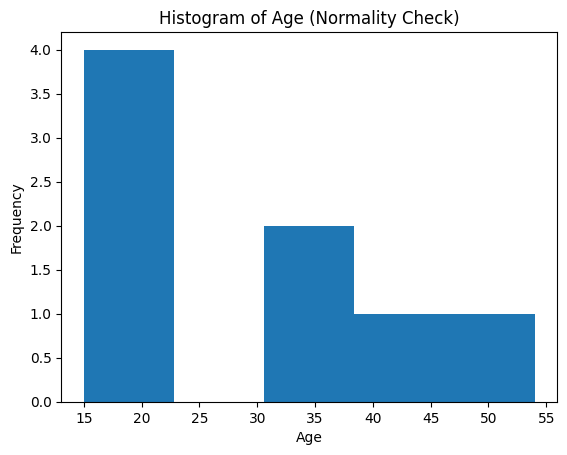

In [8]:
# Cell 4B — Check normality assumption (visual check using a histogram)
# A key assumption behind the one-sample t-test is that the sample data
# are approximately normally distributed (especially important for small n).
#
# A quick beginner-friendly check is a histogram:
# - If it looks roughly bell-shaped and symmetric, normality is more reasonable.
# - If it is extremely skewed or has extreme outliers, be cautious.

import matplotlib.pyplot as plt

plt.figure()
plt.hist(sample_data, bins=5)  # bins=30 is a simple default for beginners
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Histogram of Age (Normality Check)")
plt.show()


In [10]:
# Cell 5 — Run the one-sample t-test
# R: t.test(sample_data, mu = 50)
# SciPy: stats.ttest_1samp(sample_data, popmean=mu0)

mu0 = 50  # Null hypothesis mean

t_stat, p_value = stats.ttest_1samp(sample_data, popmean=mu0)

print("One-sample t-test result")
print("------------------------")
print("H0: mean(Age) =", mu0)
print("n:", int(len(sample_data)))
print("t-statistic:", float(t_stat))
print("p-value:    ", float(p_value))

One-sample t-test result
------------------------
H0: mean(Age) = 50
n: 8
t-statistic: -3.8427841848407436
p-value:     0.0063515655327396415
